In [2]:
from google.colab import drive
from huggingface_hub import login
import os
import gc
import torch
import torchvision
import sys
import matplotlib.pyplot as plt
import numpy as np
drive.mount('/content/drive')
gc.collect()
torch.cuda.empty_cache()
!git clone https://github.com/facebookresearch/sam3.git
!pip install -e .
!pip install segment
login()
os.chdir("/content/drive/MyDrive/Jersey_Detection/image_segmentation/sam3")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Cloning into 'sam3'...
remote: Enumerating objects: 1062, done.
remote: Counting objects: 100% (5/5), done.
remote: Compressing objects: 100% (4/4), done.
remote: Total 1062 (delta 1), reused 1 (delta 1), pack-reused 1057 (from 2)
Receiving objects: 100% (1062/1062), 60.34 MiB | 63.83 MiB/s, done.
Resolving deltas: 100% (254/254), done.
Obtaining file:///content
ERROR: file:///content does not appear to be a Python project: neither 'setup.py' nor 'pyproject.toml' found.


In [5]:

import sam3
from PIL import Image
from sam3 import build_sam3_image_model
from sam3.model.box_ops import box_xywh_to_cxcywh
from sam3.model.sam3_image_processor import Sam3Processor
from sam3.visualization_utils import draw_box_on_image, normalize_bbox, plot_results

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 2.0 MB/s eta 0:00:00


In [19]:
!pip install opencv-python

In [6]:
print("PyTorch version:", torch.__version__)
print("Torchvision version:", torchvision.__version__)
print("CUDA is available:", torch.cuda.is_available())

PyTorch version: 2.10.0+cu128
Torchvision version: 0.25.0+cu128
CUDA is available: True


In [7]:
# turn on tfloat32 for Ampere GPUs
# https://pytorch.org/docs/stable/notes/cuda.html#tensorfloat-32-tf32-on-ampere-devices
torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32 = True

# use bfloat16 for the entire notebook
torch.autocast("cuda", dtype=torch.bfloat16).__enter__()

In [8]:
#This is the directory with sam3 in it
os.chdir("/content/drive/MyDrive/Jersey_Detection/image_segmentation/sam3/sam3")

In [9]:
bpe_path = f"assets/bpe_simple_vocab_16e6.txt.gz"
model = build_sam3_image_model(bpe_path=bpe_path)

config.json: 0.00B [00:00, ?B/s]

sam3.pt:   0%|          | 0.00/3.45G [00:00<?, ?B/s]

In [10]:
processor = Sam3Processor(model, confidence_threshold = 0.5)

found 5 object(s)


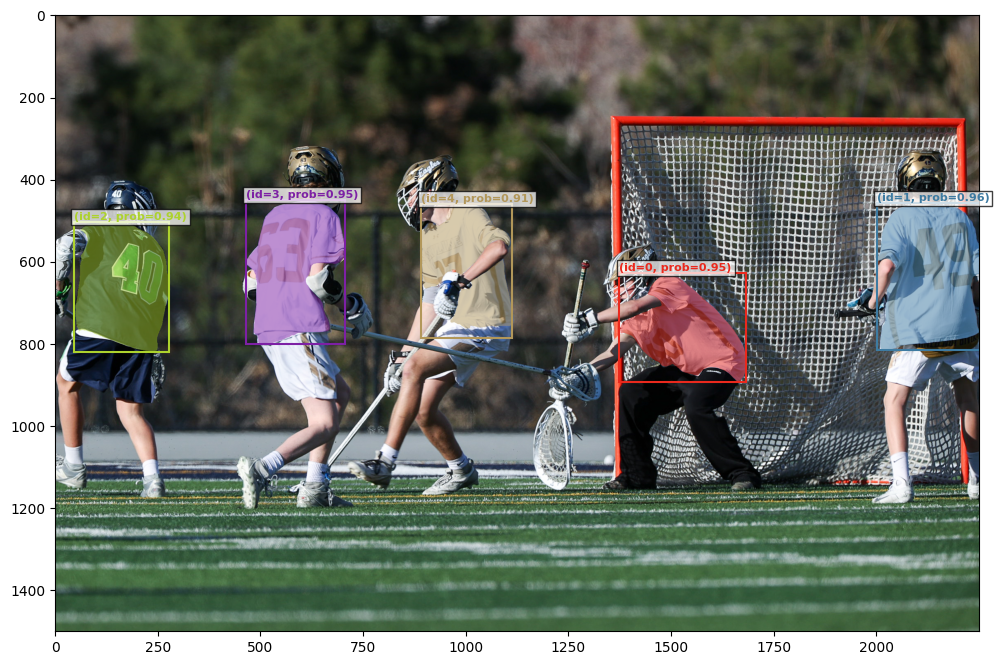

In [11]:
#Test Image
image_path = f"/content/drive/MyDrive/Group Project/Trying Gemini 2.5 Flash/Test Jersey Set/white_AF2I5061-53-49.jpg"
image = Image.open(image_path)
inference_state = processor.set_image(image)
processor.reset_all_prompts(inference_state)
#inference_state = processor.set_text_prompt(state=inference_state, prompt="playing athletes wearing white jersey top")
jersey = processor.set_text_prompt(state=inference_state, prompt="jersey top")
#inference_state = processor.set_text_prompt(state=inference_state, prompt="athletes wearing white top")
img0 = Image.open(image_path)
plot_results(img0, inference_state)

In [12]:
#distance function
def hsv_distance(c1, c2):
  v1 = min(abs(c1[0] - c2[0]), 180 - abs(c1[0] - c2[0]))
  v2 = np.abs(c1[1] - c2[1])
  v3 = np.abs(c1[2] - c2[2])
  return np.sqrt((v1)**2 + (0.2*v2)**2 + (0.1*v3)**2)

In [13]:
#HSV Values for main colors
color_vocab = {
    "white":       np.array([0,   0,   255]),
    "blue":        np.array([120, 255, 255]),
    "green":       np.array([60,  255, 255]),
    "black":       np.array([0,   0,   0]),
    "purple":      np.array([140, 255, 255]),
    "red":         np.array([0,   255, 255]),
    "orange":      np.array([15,  255, 255]),
    "yellow":      np.array([30,  255, 255]),
    "maroon":      np.array([170, 200, 150]),
    "light blue":  np.array([100, 150, 255]),
    "gray":        np.array([0,   0,   150]),
    "brown":       np.array([10,  200, 150]),
    "teal":        np.array([90,  255, 200]),
    "pink":        np.array([160, 200, 255]),
    "gold":        np.array([25,  200, 255]),
    "navy blue":   np.array([120, 255, 120]),
    "dark blue":   np.array([120, 255, 80]),
    "dark brown":  np.array([10,  200, 100]),
    "navy":        np.array([120, 255, 120]),
}

In [14]:
#Main distance function
def import_image_distance(image_path, image_color):
  image = Image.open(image_path)
  width, height = image.size
  if max(width, height) > 1200:
    scale = 1200 / max(width, height)
    new_w = int(width * scale)
    new_h = int(height * scale)
    image = image.resize((new_w, new_h))
  with torch.inference_mode():
    image_array = np.array(image)
    state1 = processor.set_image(image)
    inference_state1 = processor.set_text_prompt(state=state1, prompt="jersey top")
    jersey_color_mask = inference_state1["masks"].cpu().numpy().astype(bool)

    state2 = processor.set_image(image)
    inference_state2 = processor.set_text_prompt(state=state2, prompt="athletes")
    athletes_mask = inference_state2["masks"].cpu().numpy().astype(bool)

    image_array_adj = cv2.cvtColor(image_array, cv2.COLOR_RGB2HSV)
    jersey_color_mask = np.squeeze(jersey_color_mask, axis = 1)

    distance_filtered_masks = []
    for mask in jersey_color_mask:
      filtered_mask = image_array_adj[mask > 0]
      if image_color == 'black':
        if np.mean((filtered_mask[:, 1] < 80) & (filtered_mask[:, 2] < 80)) > 0.25:
          distance_filtered_masks.append(mask)
      elif image_color == 'white':
        #print(np.mean((filtered_mask[:, 1] < 40) & (filtered_mask[:, 2] > 180)))
        if np.mean((filtered_mask[:, 1] < 40) & (filtered_mask[:, 2] > 180)) > 0.25:
          distance_filtered_masks.append(mask)
      else:
        if len(filtered_mask) > 5000:
          filtered_mask = filtered_mask[np.random.choice(len(filtered_mask), 5000, replace = False)]
        mean = np.mean(filtered_mask, axis = 0)
        if hsv_distance(mean, color_vocab[image_color]) > 80:
          continue
        dist = np.linalg.norm(filtered_mask - mean, axis=1)
        filtered_mask_new = filtered_mask[dist < np.percentile(dist, 70)]
        avg_color = np.median(filtered_mask_new, axis = 0)
        distance = hsv_distance(avg_color, color_vocab[image_color])
        if image_color == 'green':
          if distance <= 40:
            distance_filtered_masks.append(mask)
        elif image_color == 'navy blue':
          if distance <= 35:
            distance_filtered_masks.append(mask)
        elif distance <= 40:
          distance_filtered_masks.append(mask)
        del dist, filtered_mask_new
      del filtered_mask

    if len(distance_filtered_masks) == 0:
        distance_filtered_masks = jersey_color_mask

    if len(jersey_color_mask) == 0:
        result_img = Image.fromarray(np.zeros(image_array.shape).astype(np.uint8))


    else:
      del jersey_color_mask

      masks_jersey_color = np.zeros_like(distance_filtered_masks[0], dtype = bool)

      for color_mask in distance_filtered_masks:
        masks_jersey_color |= color_mask

      del distance_filtered_masks

      full_masks = []
      for athlete in athletes_mask:
        if ((masks_jersey_color & athlete).sum() / athlete.sum()) > 0.1:
          full_masks.append(athlete)
      del athletes_mask, masks_jersey_color
      overall_mask = np.zeros((image_array.shape[0], image_array.shape[1]), dtype = bool)
      for mask in full_masks:
        mask = np.squeeze(mask, axis = 0)
        overall_mask |= mask.astype(bool)
        #bool_mask = mask.astype(np.uint8)
        #temp_mask = np.zeros((image_array.shape[0], image_array.shape[1], image_array.shape[2]))
        #for i in range(3):
          # temp_mask[:,:, i] = bool_mask
        #overall_mask = np.maximum(overall_mask, temp_mask)
        #full_mask = (image_array * overall_mask)

      full_mask = image_array.copy()
      full_mask[~overall_mask] = 0
      result_img = Image.fromarray(full_mask.astype(np.uint8))
  del state1, inference_state1, state2, inference_state2
  torch.cuda.empty_cache()
  updated_path = image_path.split("/")[-1]
  # If you want to save the image
  result_img.save(f"/content/drive/MyDrive/Group Project/Trying Gemini 2.5 Flash/Sam3Images194/{updated_path}")

  #If you want to output it instead
  plt.imshow(result_img)
  plt.axis("off")  # Hide the axis
  plt.show()

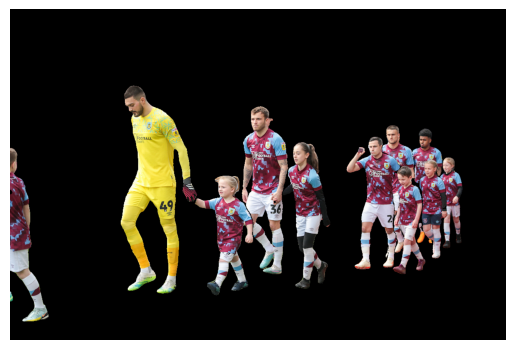

In [22]:
import_image_distance('/content/drive/MyDrive/Group Project/Trying Gemini 2.5 Flash/updated jersey numbers colors/maroon_B63W2111-4-36-24.jpg', 'maroon')

In [ ]:
#Loop Through all images
image_folder = Path("/content/drive/MyDrive/Group Project/Trying Gemini 2.5 Flash/updated jersey numbers colors/")
image_files = [str(f) for f in image_folder.iterdir() if f.is_file()]
cur_image = 1
for img_path in image_files:
  color = img_path.split('/')[7].split('_')[0]
  print(f"Cur_Image: {img_path}")
  print(f"Image: {cur_image}/{len(image_files)}")
  print(f"Color: {color}")
  import_image_distance(img_path, color)
  cur_image += 1

Cur_Image: /content/drive/MyDrive/Group Project/Trying Gemini 2.5 Flash/updated jersey numbers colors/maroon_1135-none.jpg
Image: 127/194
Color: maroon
Cur_Image: /content/drive/MyDrive/Group Project/Trying Gemini 2.5 Flash/updated jersey numbers colors/maroon_B63W3299-none.jpg
Image: 128/194
Color: maroon
Cur_Image: /content/drive/MyDrive/Group Project/Trying Gemini 2.5 Flash/updated jersey numbers colors/maroon_1133-none.jpg
Image: 129/194
Color: maroon
Cur_Image: /content/drive/MyDrive/Group Project/Trying Gemini 2.5 Flash/updated jersey numbers colors/maroon_B63W5583-10.jpg
Image: 130/194
Color: maroon
Cur_Image: /content/drive/MyDrive/Group Project/Trying Gemini 2.5 Flash/updated jersey numbers colors/maroon_1116-23-10.jpg
Image: 131/194
Color: maroon
Cur_Image: /content/drive/MyDrive/Group Project/Trying Gemini 2.5 Flash/updated jersey numbers colors/maroon_1136-23.jpg
Image: 132/194
Color: maroon
Cur_Image: /content/drive/MyDrive/Group Project/Trying Gemini 2.5 Flash/updated jer

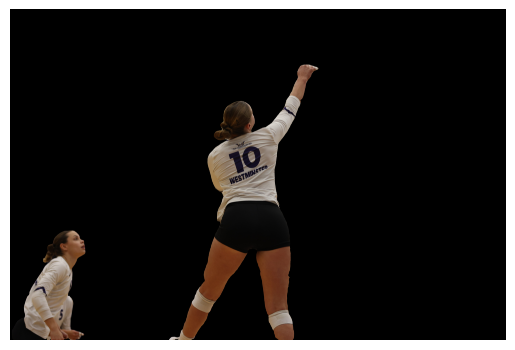

In [ ]:
image_array = np.array(image)
state1 = processor.set_image(image)
inference_state1 = processor.set_text_prompt(state=state1, prompt="white jersey top")
jersey_color_mask = inference_state1["masks"].cpu()

state2 = processor.set_image(image)
inference_state2 = processor.set_text_prompt(state=state1, prompt="team athletes")
athletes_mask = inference_state2["masks"].cpu()
masks_jersey_color = np.zeros_like(jersey_color_mask[0], dtype = bool)

for color_mask in jersey_color_mask:
  masks_jersey_color |= color_mask.numpy()

full_masks = []
for athlete in athletes_mask:
  ath_arr = athlete.numpy()
  jersey_area = (masks_jersey_color & ath_arr)
  overlap =  jersey_area.sum() / ath_arr.sum()
  if overlap > 0.25 :
    full_masks.append(athlete)
full_masks = np.squeeze(full_masks, axis = 1)
overall_mask = np.zeros((image_array.shape[0], image_array.shape[1], image_array.shape[2]))

for mask in full_masks:
  bool_mask = mask.astype(np.uint8)
  temp_mask = np.zeros((image_array.shape[0], image_array.shape[1], image_array.shape[2]))
  for i in range(3):
      temp_mask[:,:, i] = bool_mask
  overall_mask = np.maximum(overall_mask, temp_mask)
  del bool_mask, temp_mask
  full_mask = (image_array * overall_mask)
del overall_mask
result_img = Image.fromarray(full_mask.astype(np.uint8))
plt.imshow(result_img)
plt.axis("off")  # Hide the axis
plt.show()

In [ ]:
import segment
import importlib
from pathlib import Path
import gc
#image_folder = Path("/content/drive/MyDrive/Group Project/Trying Gemini 2.5 Flash/jersey numbers")
image_folder = Path("/content/drive/MyDrive/Group Project/Trying Gemini 2.5 Flash/updated jersey numbers colors")
image_files = [str(f) for f in image_folder.iterdir() if f.is_file()]
processor = Sam3Processor(model, confidence_threshold=0.4)

In [ ]:
def import_image_updated(image_path, image_color):
  image = Image.open(image_path)
  image_array = np.array(image)
  overall_mask = np.zeros((image_array.shape[0], image_array.shape[1], image_array.shape[2]))
  with torch.inference_mode():
    state1 = processor.set_image(image)
    inference_state1 = processor.set_text_prompt(state=state1, prompt=f"{image_color} jersey")
    jersey_color_mask = inference_state1["masks"].cpu()

    state2 = processor.set_image(image)
    inference_state2 = processor.set_text_prompt(state=state1, prompt="athletes")
    athletes_mask = inference_state2["masks"].cpu()

    if len(athletes_mask > 0) and len(jersey_color_mask > 0):
      masks_jersey_color = np.zeros_like(jersey_color_mask[0], dtype = bool)
      for color_mask in jersey_color_mask:
        masks_jersey_color |= color_mask.numpy()
      print("Image Segmented")
      full_masks = []
      for athlete in athletes_mask:
        ath_arr = athlete.numpy()
        jersey_area = (masks_jersey_color & ath_arr)
        overlap =  jersey_area.sum() / ath_arr.sum()
        if overlap > 0.25 :
          full_masks.append(athlete)

    else:
      print("3rd Prompt")
      state1 = processor.set_image(image)
      inference_state1 = processor.set_text_prompt(state=state1, prompt=f"Whole Athletes with {image_color} Jersey Tops")
      full_masks = inference_state1["masks"].cpu().numpy()
      if len(full_masks) == 0:
        result_img = Image.fromarray(overall_mask.astype(np.uint8))
        updated_path = image_path.split("/")[-1]
        result_img.save(f"/content/drive/MyDrive/Jersey_Detection/image_segmentation/outputs/sam3ImagesColor/{updated_path}")
        print("No People Found")
        return

    full_masks = np.squeeze(full_masks, axis = 1)


    for mask in full_masks:
      bool_mask = mask.astype(np.uint8)
      temp_mask = np.zeros((image_array.shape[0], image_array.shape[1], image_array.shape[2]))
      for i in range(3):
          temp_mask[:,:, i] = bool_mask
      overall_mask = np.maximum(overall_mask, temp_mask)
      #del bool_mask, temp_mask
      full_mask = (image_array * overall_mask)
    #del overall_mask
    result_img = Image.fromarray(full_mask.astype(np.uint8))
    updated_path = image_path.split("/")[-1]
    result_img.save(f"/content/drive/MyDrive/Jersey_Detection/image_segmentation/outputs/sam3ImagesColor/{updated_path}")
    #del result_img, image, inference_state1, inference_state2, full_mask
    print("Background Removed & Image Saved")

In [ ]:
cur_image = 124
for img_path in image_files[124:]:
  color = img_path.split('/')[7].split('_')[0]
  print(f"Cur_Image: {img_path}")
  print(f"Image: {cur_image}/{len(image_files)}")
  print(f"Color: {color}")
  #import_image(img_path, val)
  import_image_updated(img_path, color)
  cur_image += 1

Cur_Image: /content/drive/MyDrive/Group Project/Trying Gemini 2.5 Flash/updated jersey numbers colors/maroon_B63W8591-5-29-27-45.jpg
Image: 124/194
Color: maroon
Image Segmented
Background Removed & Image Saved
Cur_Image: /content/drive/MyDrive/Group Project/Trying Gemini 2.5 Flash/updated jersey numbers colors/maroon_1135-none.jpg
Image: 125/194
Color: maroon
3rd Prompt
No People Found
Cur_Image: /content/drive/MyDrive/Group Project/Trying Gemini 2.5 Flash/updated jersey numbers colors/maroon_B63W3299-none.jpg
Image: 126/194
Color: maroon
3rd Prompt
Background Removed & Image Saved
Cur_Image: /content/drive/MyDrive/Group Project/Trying Gemini 2.5 Flash/updated jersey numbers colors/maroon_1133-none.jpg
Image: 127/194
Color: maroon
Image Segmented
Background Removed & Image Saved
Cur_Image: /content/drive/MyDrive/Group Project/Trying Gemini 2.5 Flash/updated jersey numbers colors/maroon_B63W5583-10.jpg
Image: 128/194
Color: maroon
3rd Prompt
Background Removed & Image Saved
Cur_Image: 